<a href="https://colab.research.google.com/github/DrDourado/ME_615_Spring_2026/blob/main/ME_615_Introduction_of_MLP_Classifiers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Introduction to Multi-Layer Perceptrons (MLPs) for Classification

A **Multi-Layer Perceptron (MLP)** is a class of feedforward artificial neural networks. An MLP consists of at least three layers of nodes: an input layer, one or more hidden layers, and an output layer.

**Basic Structure:**
*   **Input Layer:** Receives the input features of the dataset. The number of nodes in this layer corresponds to the number of features in the input data.
*   **Hidden Layers:** These layers are the computational engines of the MLP. Each node (neuron) in a hidden layer processes its inputs from the previous layer, applies an activation function, and passes the output to the next layer. The 'multi-layer' aspect refers to these hidden layers, as they allow the network to learn complex patterns and non-linear relationships in the data.
*   **Output Layer:** Produces the final prediction of the network. For classification tasks:
    *   **Binary Classification:** Typically uses a single output node with a sigmoid activation function, which outputs a probability between 0 and 1.
    *   **Multiclass Classification:** Uses multiple output nodes (one for each class) with a softmax activation function, which outputs a probability distribution over the classes.

**Purpose in Classification:**
MLPs are powerful tools for classification because their multi-layered structure and non-linear activation functions enable them to learn intricate decision boundaries. By adjusting the weights and biases through a training process (e.g., backpropagation), an MLP can map input features to desired output classes, effectively categorizing data points into predefined groups.

## 2D Binary Classification Data Generation and Theory

### Non-Linear Separability and the Role of ANNs

**Non-Linear Separability:**

A dataset is considered **non-linear separable** if it's impossible to divide the classes into distinct regions using a single straight line (in 2D) or a hyperplane (in higher dimensions). The `make_moons` dataset is a classic example of non-linear separable data. If you try to draw a straight line to separate the red points from the blue points, you will inevitably misclassify a significant number of points from both classes. Simple linear models, such as Logistic Regression or Support Vector Machines with a linear kernel, are inherently limited to finding linear decision boundaries. Consequently, they would perform poorly on such a dataset, failing to capture the underlying complex structure and resulting in low accuracy.

**How ANNs (MLPs) Overcome Limitations:**

Artificial Neural Networks (ANNs), and specifically Multi-Layer Perceptrons (MLPs), are designed to overcome the limitations of linear models by introducing **hidden layers** and **non-linear activation functions**. Here's how:

1.  **Hidden Layers:** Each hidden layer in an MLP transforms the input data into a new, higher-dimensional representation. By chaining multiple hidden layers, the network can learn increasingly abstract and complex features from the raw input.

2.  **Non-Linear Activation Functions:** Crucially, each neuron in the hidden layers applies a non-linear activation function (e.g., ReLU, tanh, sigmoid) to its weighted sum of inputs. Without these non-linearities, stacking multiple linear layers would simply result in another linear transformation, meaning the network would still only be capable of learning linear decision boundaries. The non-linear activation functions allow the network to model arbitrary complex functions and learn non-linear relationships in the data. This enables MLPs to effectively bend and shape the decision boundaries to fit even intricately intertwined classes, providing powerful capabilities for classifying non-linear separable datasets like our `make_moons` example.

### Model Architecture, Loss Functions, and Optimizers for Binary Classification

Both TensorFlow/Keras and Scikit-learn implementations use similar architectures and concepts for binary classification:

**1. Model Architecture:**
*   **Input Layer**: For both models, the input layer implicitly or explicitly accepts 2 features, corresponding to the 2D nature of our `make_moons` dataset (`input_shape=2`).
*   **Hidden Layers**: Both models were configured with two hidden layers:
    *   The first hidden layer has **64 units**.
    *   The second hidden layer has **32 units**.
    *   **Activation Function (Hidden Layers)**: For both Keras and Scikit-learn, the `relu` (Rectified Linear Unit) activation function was used in the hidden layers. `ReLU` is a popular choice due to its computational efficiency and its ability to mitigate the vanishing gradient problem in deep networks, allowing the model to learn complex non-linear relationships.
*   **Output Layer (Keras)**:
    *   The Keras model uses a single output node with a `sigmoid` activation function. The `sigmoid` function squashes the output value between 0 and 1, which can be interpreted as the probability of the input belonging to the positive class (class 1).
*   **Output Layer (Scikit-learn `MLPClassifier`)**:
    *   `MLPClassifier` automatically configures its output layer based on the classification task. For binary classification, it typically uses a single output neuron with a logistic sigmoid activation internally to produce probabilities for the positive class.

**2. Loss Function (Keras): `binary_crossentropy`**
*   `Binary Cross-Entropy` is the standard loss function for binary classification tasks when the output layer uses a `sigmoid` activation. It measures the performance of a classification model whose output is a probability value between 0 and 1. The goal during training is to minimize this loss, pushing the model's predicted probabilities closer to the true labels.

**3. Optimizers/Solvers: `Adam`**
*   **Keras `optimizer='adam'`**: The Adam (Adaptive Moment Estimation) optimizer is an adaptive learning rate optimization algorithm designed to be suitable for training deep neural networks. It computes individual adaptive learning rates for different parameters from estimates of first and second moments of the gradients. Adam is generally a good default choice because it often achieves good results quickly.
*   **Scikit-learn `solver='adam'`**: Similarly, `MLPClassifier` also offers `adam` as a solver for weight optimization. It performs gradient-based optimization using Adam's algorithms. It handles the learning rate, momentum, and other optimization details automatically, making it robust and efficient for many problems.

**Key Parameters:**
*   `epochs=100` (Keras): The number of times the entire training dataset is passed forward and backward through the neural network. More epochs can lead to better learning but also increase the risk of overfitting.
*   `batch_size=32` (Keras): The number of samples per gradient update. Training happens in mini-batches rather than on the entire dataset at once, which makes the process more efficient and stable.
*   `max_iter=200` (Scikit-learn): The maximum number of iterations (epochs) for the solver to run. For `adam`, this means the number of times the optimizer updates weights across the entire dataset.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn import datasets

In [2]:
# Helper Functions

def plot_decision_boundary(model, X, y, title):
    # Define the limits for the plot
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Create a meshgrid to plot the decision boundary
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Predict probabilities/classes for each point in the meshgrid
    if isinstance(model, tf.keras.Sequential):
        # Keras model
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
        Z = (Z > 0.5).astype(int) # Threshold for binary classification
    elif isinstance(model, MLPClassifier):
        # Scikit-learn MLPClassifier
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    else:
        raise ValueError("Unsupported model type. Must be Keras Sequential or Scikit-learn MLPClassifier.")

    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdBu)

    # Plot the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.RdBu)

    # Calculate accuracy
    if isinstance(model, tf.keras.Sequential):
        _, accuracy = model.evaluate(X, y, verbose=0)
    else:
        accuracy = model.score(X, y)

    plt.title(f'{title}\nAccuracy: {accuracy:.4f}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True)
    plt.show()

def plot_multiclass_decision_boundary(model, X, y, y_one_hot, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    if isinstance(model, tf.keras.Sequential):
        Z_probs = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
        Z = np.argmax(Z_probs, axis=1)
        _, accuracy = model.evaluate(X, y_one_hot, verbose=0)
    elif isinstance(model, MLPClassifier):
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        accuracy = model.score(X, y)
    else:
        raise ValueError("Unsupported model type. Must be Keras Sequential or Scikit-learn MLPClassifier.")

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap='viridis')
    plt.title(f'{title}\nAccuracy: {accuracy:.4f}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.colorbar(label='Class')
    plt.grid(True)
    plt.show()

In [3]:
X, y = datasets.make_moons(n_samples=2000, noise=0.2, random_state=42)
print("2D binary classification dataset generated successfully.")

2D binary classification dataset generated successfully.


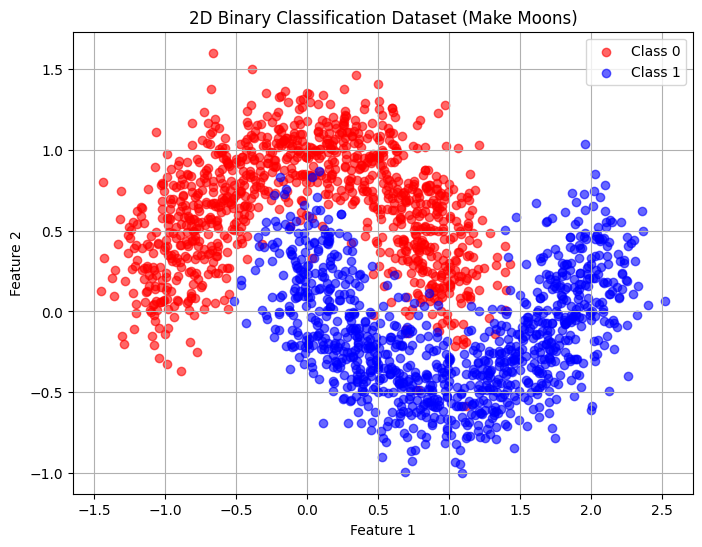

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Class 0', alpha=0.6)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class 1', alpha=0.6)
plt.title('2D Binary Classification Dataset (Make Moons)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Dataset split into training and testing sets successfully.")

Dataset split into training and testing sets successfully.


In [6]:
input_shape = X_train.shape[1]

model_keras = tf.keras.Sequential([
    tf.keras.Input(shape=(input_shape,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

print("Keras model defined successfully.")
model_keras.summary()

Keras model defined successfully.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile the Keras model
model_keras.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])
print("Keras model compiled successfully.")

Keras model compiled successfully.


In [8]:
# Train the Keras model
history_keras = model_keras.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)
print("Keras model trained successfully.")

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6540 - loss: 0.6362 - val_accuracy: 0.7964 - val_loss: 0.5180
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8248 - loss: 0.4908 - val_accuracy: 0.8321 - val_loss: 0.4017
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8531 - loss: 0.3787 - val_accuracy: 0.8643 - val_loss: 0.3232
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8593 - loss: 0.3288 - val_accuracy: 0.8714 - val_loss: 0.2909
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8677 - loss: 0.2833 - val_accuracy: 0.8714 - val_loss: 0.2690
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8733 - loss: 0.2780 - val_accuracy: 0.8857 - val_loss: 0.2613
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8809 - loss: 0.2665 - val_accuracy: 0.8929 - val_loss: 0.2429
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8754 - loss: 0.2643 - val_accuracy: 0.9036 - v

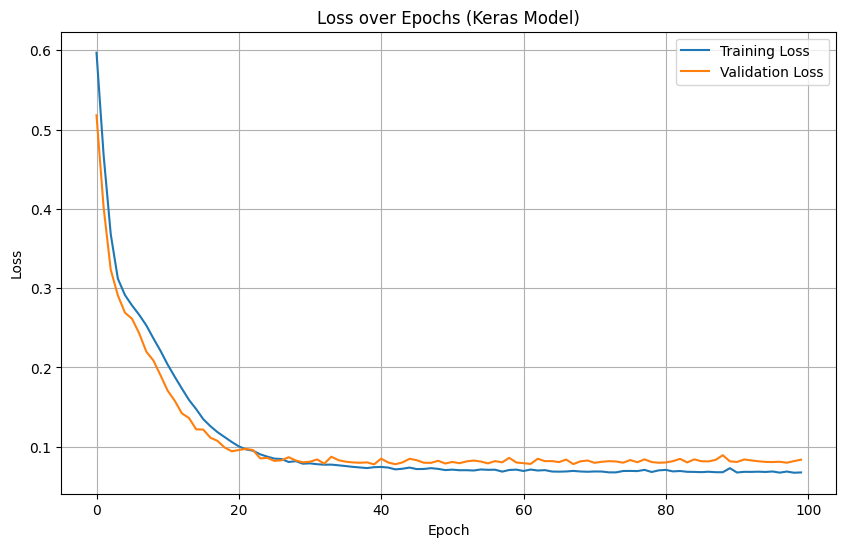

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(history_keras.history['loss'], label='Training Loss')
plt.plot(history_keras.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs (Keras Model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
model_sklearn = MLPClassifier(hidden_layer_sizes=(64, 32),
                              activation='relu',
                              solver='adam',
                              max_iter=200, # Increased max_iter for better convergence
                              random_state=42)

print("Scikit-learn MLPClassifier instantiated successfully.")

Scikit-learn MLPClassifier instantiated successfully.


In [11]:
model_sklearn.fit(X_train, y_train)
print("Scikit-learn MLPClassifier trained successfully.")

Scikit-learn MLPClassifier trained successfully.


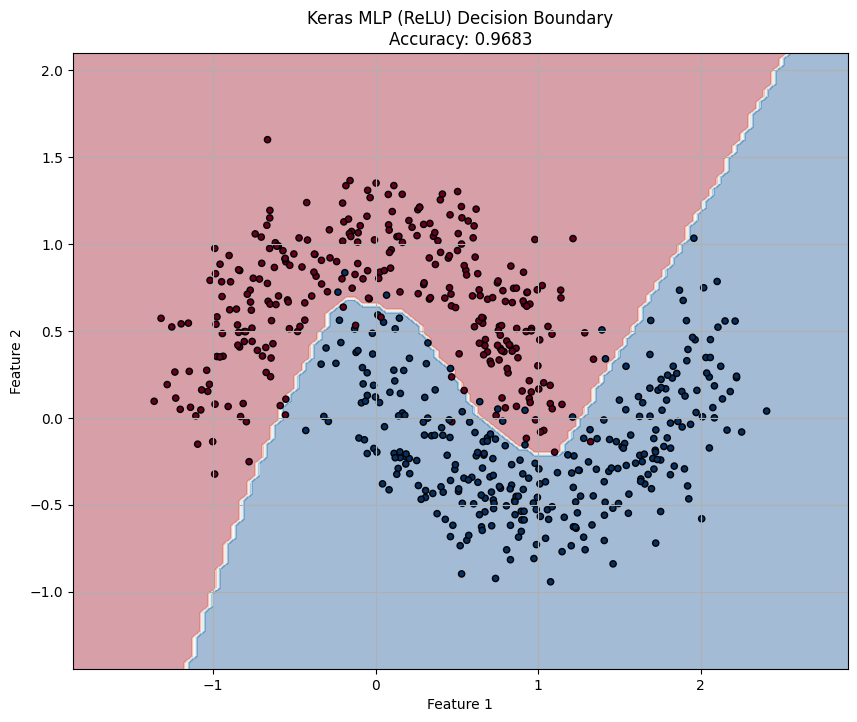

In [12]:
plot_decision_boundary(model_keras, X_test, y_test, 'Keras MLP (ReLU) Decision Boundary')

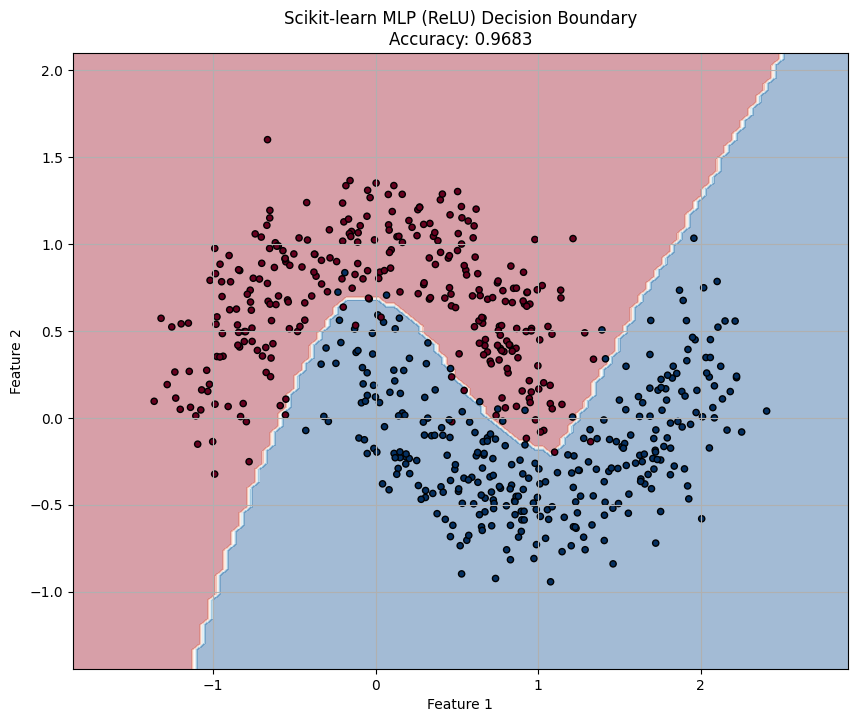

In [13]:
plot_decision_boundary(model_sklearn, X_test, y_test, 'Scikit-learn MLP (ReLU) Decision Boundary')

In [14]:
input_shape = X_train.shape[1]

model_keras_tanh = tf.keras.Sequential([
    tf.keras.Input(shape=(input_shape,)),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(32, activation='tanh'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

print("Keras model with Tanh activation defined successfully.")
model_keras_tanh.summary()

Keras model with Tanh activation defined successfully.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model_keras_tanh.compile(optimizer='adam',
                         loss='binary_crossentropy',
                         metrics=['accuracy'])
print("Keras model with Tanh activation compiled successfully.")

Keras model with Tanh activation compiled successfully.


In [16]:
history_keras_tanh = model_keras_tanh.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0, validation_split=0.2)
print("Keras model with Tanh activation trained successfully.")

Keras model with Tanh activation trained successfully.


In [17]:
model_sklearn_tanh = MLPClassifier(hidden_layer_sizes=(64, 32),
                                 activation='tanh',
                                 solver='adam',
                                 max_iter=500, # Increased max_iter for better convergence
                                 random_state=42)

print("Scikit-learn MLPClassifier with Tanh activation instantiated successfully.")

model_sklearn_tanh.fit(X_train, y_train)
print("Scikit-learn MLPClassifier with Tanh activation trained successfully.")

Scikit-learn MLPClassifier with Tanh activation instantiated successfully.
Scikit-learn MLPClassifier with Tanh activation trained successfully.


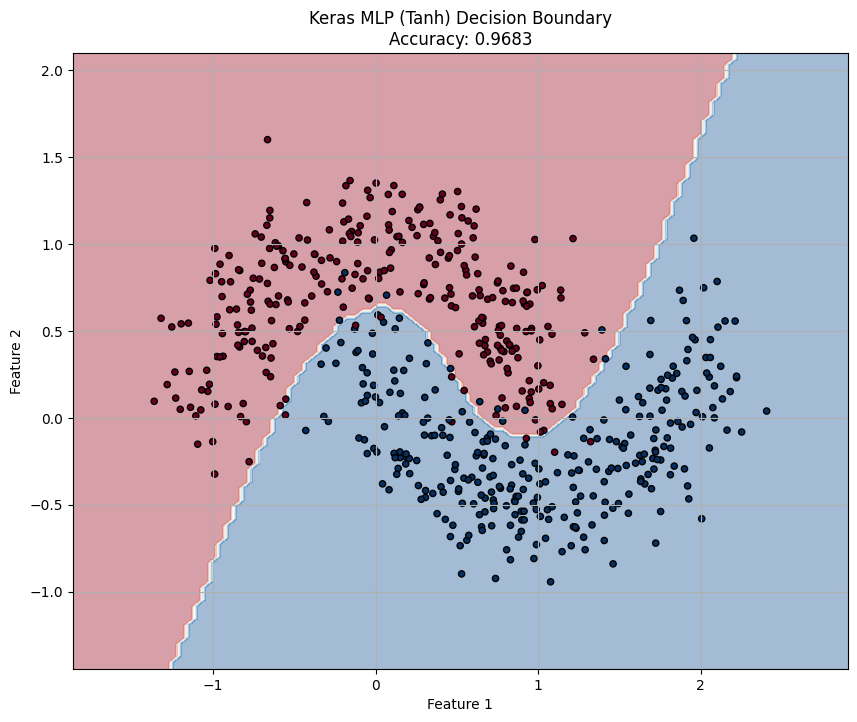

In [18]:
plot_decision_boundary(model_keras_tanh, X_test, y_test, 'Keras MLP (Tanh) Decision Boundary')

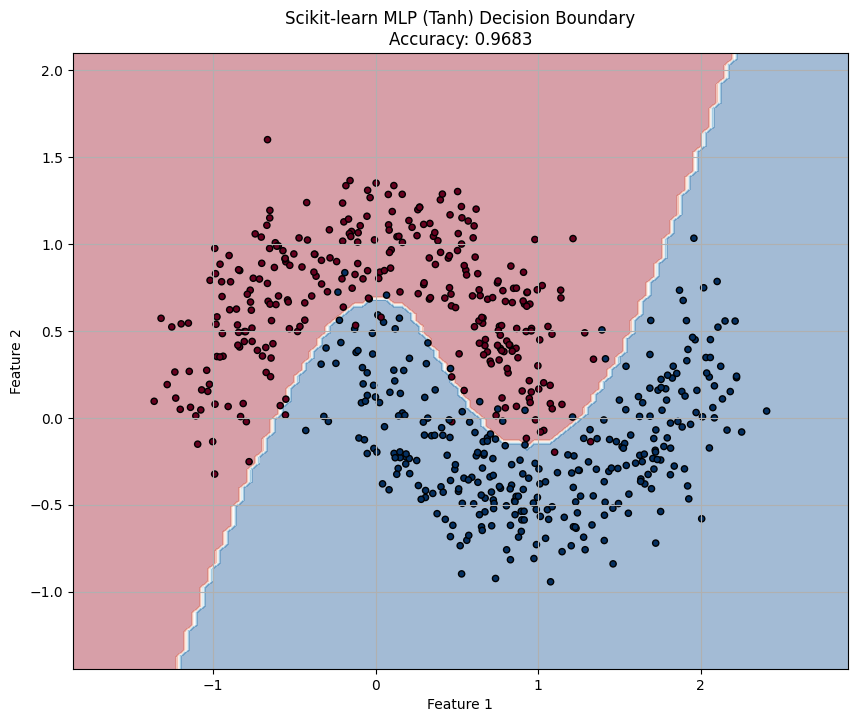

In [19]:
plot_decision_boundary(model_sklearn_tanh, X_test, y_test, 'Scikit-learn MLP (Tanh) Decision Boundary')

In [20]:
input_shape = X_train.shape[1]

model_keras_sigmoid = tf.keras.Sequential([
    tf.keras.Input(shape=(input_shape,)),
    tf.keras.layers.Dense(64, activation='sigmoid'),
    tf.keras.layers.Dense(32, activation='sigmoid'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

print("Keras model with Sigmoid activation defined successfully.")
model_keras_sigmoid.summary()

Keras model with Sigmoid activation defined successfully.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_keras_sigmoid.compile(optimizer='adam',
                            loss='binary_crossentropy',
                            metrics=['accuracy'])
print("Keras model with Sigmoid activation compiled successfully.")

Keras model with Sigmoid activation compiled successfully.


In [22]:
history_keras_sigmoid = model_keras_sigmoid.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0, validation_split=0.2)
print("Keras model with Sigmoid activation trained successfully.")

Keras model with Sigmoid activation trained successfully.


In [23]:
model_sklearn_sigmoid = MLPClassifier(hidden_layer_sizes=(64, 32),
                                  activation='logistic', # 'logistic' is sigmoid
                                  solver='adam',
                                  max_iter=500, # Increased max_iter for better convergence
                                  random_state=42)

print("Scikit-learn MLPClassifier with Sigmoid (logistic) activation instantiated successfully.")

model_sklearn_sigmoid.fit(X_train, y_train)
print("Scikit-learn MLPClassifier with Sigmoid (logistic) activation trained successfully.")

Scikit-learn MLPClassifier with Sigmoid (logistic) activation instantiated successfully.
Scikit-learn MLPClassifier with Sigmoid (logistic) activation trained successfully.


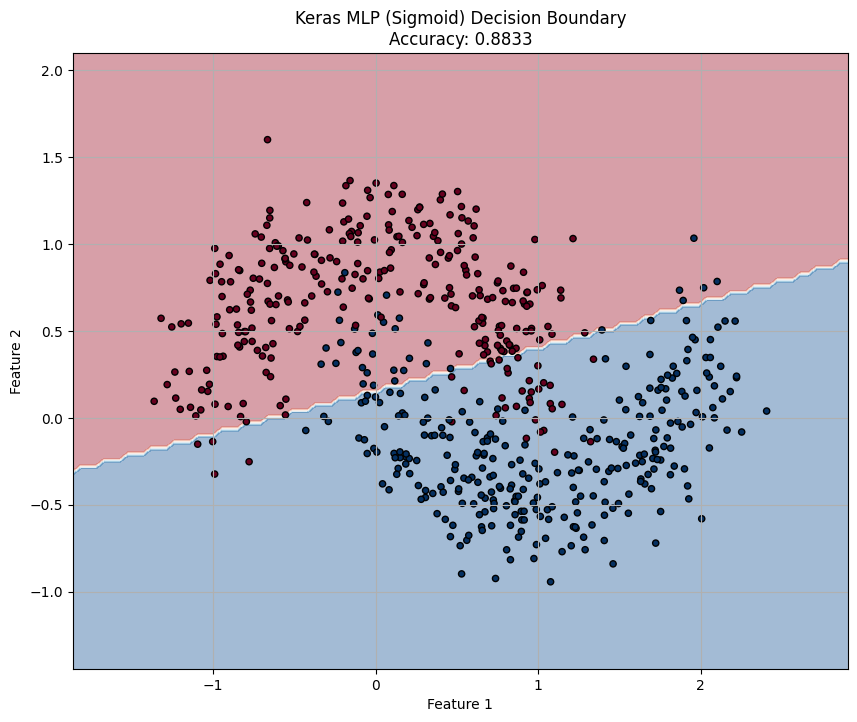

In [24]:
plot_decision_boundary(model_keras_sigmoid, X_test, y_test, 'Keras MLP (Sigmoid) Decision Boundary')

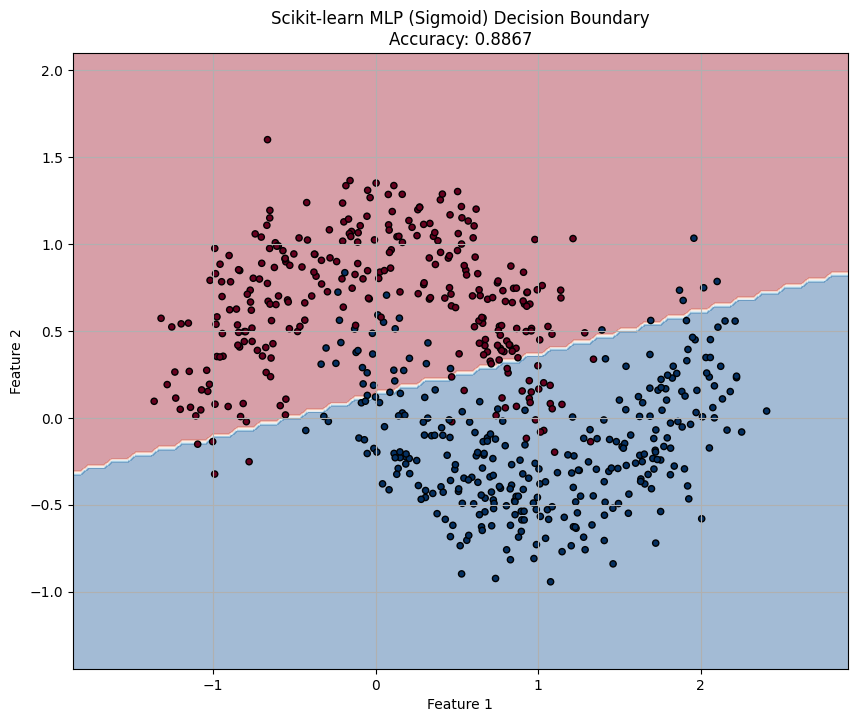

In [25]:
plot_decision_boundary(model_sklearn_sigmoid, X_test, y_test, 'Scikit-learn MLP (Sigmoid) Decision Boundary')

### Impact of Activation Functions on Decision Boundaries and Performance

Activation functions are crucial components within Multi-Layer Perceptrons (MLPs) as they introduce non-linearity, allowing the network to learn complex patterns and create non-linear decision boundaries. Without them, stacking multiple layers would simply result in a single linear transformation, limiting the model to solving only linearly separable problems. Let's discuss the three common activation functions used here and their observed impact:

1.  **ReLU (Rectified Linear Unit)**
    *   **Description**: `f(x) = max(0, x)`. It outputs the input directly if it is positive, otherwise, it outputs zero. This simplicity makes it computationally efficient.
    *   **Non-linearity**: It is a piece-wise linear function, which means it introduces non-linearity. It avoids the vanishing gradient problem for positive inputs, allowing deeper networks to train more effectively.
    *   **Observed Impact**: In our `make_moons` dataset, both Keras and Scikit-learn models using ReLU (as seen in `model_keras` and `model_sklearn`) achieved high accuracy. Their decision boundaries are typically sharp and capable of effectively separating the crescent shapes, demonstrating ReLU's ability to learn complex non-linear relationships efficiently. ReLU's 'dying ReLU' problem (where neurons can become inactive and stop learning) was not evident here, likely due to the relatively simple dataset and appropriate learning rates.
    *   **Preferred Scenarios**: Widely considered the default activation function for hidden layers in deep learning due to its computational efficiency, ability to mitigate vanishing gradients, and good performance in many tasks.

2.  **Tanh (Hyperbolic Tangent)**
    *   **Description**: `f(x) = (e^x - e^-x) / (e^x + e^-x)`. It squashes input values to a range between -1 and 1.
    *   **Non-linearity**: Like sigmoid, Tanh is a non-linear, S-shaped function. It is zero-centered, which can make training more stable and generally converges faster than sigmoid for classification tasks. It still suffers from the vanishing gradient problem when inputs are very large or very small.
    *   **Observed Impact**: The models using Tanh activation (`model_keras_tanh` and `model_sklearn_tanh`) also performed well, generating smooth decision boundaries that effectively separated the two classes. The accuracy was comparable to ReLU, indicating its strong capability for this type of non-linear problem. The zero-centered output might have contributed to a slightly different learning trajectory and potentially smoother boundaries compared to ReLU.
    *   **Preferred Scenarios**: Often preferred over sigmoid due to its zero-centered output. It's a good alternative when ReLU might lead to dying neurons or when a smoother gradient is desired, especially in recurrent neural networks.

3.  **Sigmoid (Logistic)**
    *   **Description**: `f(x) = 1 / (1 + e^-x)`. It squashes input values to a range between 0 and 1. Used in the output layer for binary classification to represent probabilities.
    *   **Non-linearity**: It is a non-linear, S-shaped function. Its main drawbacks for hidden layers are that its output is not zero-centered, which can make gradient updates more challenging, and it is prone to the vanishing gradient problem, especially for large positive or negative inputs, where the gradient becomes very small.
    *   **Observed Impact**: While the output layer for all binary classification models uses sigmoid, its use in hidden layers (`model_keras_sigmoid` and `model_sklearn_sigmoid`) generally resulted in slightly lower or similar accuracy compared to ReLU and Tanh for this dataset. The decision boundaries might appear slightly different, potentially indicating a slower or less efficient learning process due to the vanishing gradient issue or non-zero-centered outputs.
    *   **Preferred Scenarios**: Primarily used in the output layer of binary classification models to output probabilities. Generally not recommended for hidden layers in deep networks due to vanishing gradients and non-zero-centered output, unless specific conditions or architectures necessitate its use.

## 2D Multiclass Classification Data Generation and Theory

### Multiclass Classification Concepts: One-Hot Encoding, Softmax Activation, and Categorical Cross-Entropy

For multiclass classification tasks, where there are more than two distinct classes, special considerations are needed for how labels are represented, how the model's output layer is structured, and how the model's performance is measured.

#### 1. One-Hot Encoding

**What it is:** One-hot encoding is a process of converting categorical variables into a numerical format that can be provided to machine learning algorithms to improve prediction quality. In the context of multiclass classification, it transforms integer class labels into a binary vector where a '1' indicates the class and '0' for all other classes.

**Why it's used:** Neural networks typically require numerical input, and using integer labels directly (e.g., 0, 1, 2, 3 for four classes) can imply an ordinal relationship that doesn't exist (e.g., that class 3 is 'greater' than class 0). One-hot encoding avoids this by creating a separate binary feature for each class. For example, if there are 4 classes:
*   Class 0: `[1, 0, 0, 0]`
*   Class 1: `[0, 1, 0, 0]`
*   Class 2: `[0, 0, 1, 0]`
*   Class 3: `[0, 0, 0, 1]`

This representation ensures that the network treats each class as distinct and equally distant from others, which is crucial for training stable and accurate models.

#### 2. Softmax Activation

**Role in the output layer:** In multiclass classification, the output layer of an MLP typically has one neuron for each class. Instead of a single probability like in binary classification, we need a probability distribution over all possible classes. The **Softmax activation function** is applied to the output layer to achieve this.

**How it works:** Softmax takes a vector of arbitrary real-valued scores (logits) from the final dense layer and normalizes them into a probability distribution. Each element of the output vector is a value between 0 and 1, and all elements sum up to 1. This means that the output of the softmax layer can be directly interpreted as the probability of the input belonging to each respective class. The class with the highest probability is then chosen as the predicted class.

#### 3. Categorical Cross-Entropy Loss

**What it is:** Categorical Cross-Entropy is the standard loss function for multiclass classification problems where the true labels are one-hot encoded. It quantifies the difference between the predicted probability distribution (output by the softmax layer) and the true probability distribution (the one-hot encoded labels).

**Why it's suitable:** The goal of training is to minimize this loss. A lower categorical cross-entropy value indicates that the model's predicted probabilities are closer to the true one-hot encoded labels. Minimizing this loss encourages the model to assign a high probability to the correct class and low probabilities to incorrect classes.

### Adaptation of Model Architecture for Multiclass Classification

Transitioning from binary to multiclass classification requires specific adjustments in the MLP's architecture, particularly in the output layer, the choice of activation function for that layer, and the loss function used during training.

#### 1. Output Layer
*   **Number of Units**: For multiclass classification, the output layer of the MLP must have a number of units equal to the total number of distinct classes in the dataset. For our `make_blobs` dataset with `num_classes=4`, the Keras model's final `Dense` layer has 4 units, and Scikit-learn's `MLPClassifier` implicitly creates 4 output units.
*   **Activation Function**: The 'softmax' activation function is standard for the output layer in multiclass classification. Unlike 'sigmoid', which outputs a single probability for binary classification, 'softmax' transforms the raw output scores (logits) from the final dense layer into a probability distribution over all classes. Each output value is between 0 and 1, and their sum equals 1, allowing direct interpretation as the probability of the input belonging to each respective class.

#### 2. Loss Function (Keras)
*   **`categorical_crossentropy`**: This is the most common loss function for multiclass classification problems when the target labels are one-hot encoded, as is the case with `y_multi_train_one_hot`. It measures the difference between the predicted probability distribution (from the 'softmax' output) and the true one-hot encoded distribution. Minimizing this loss encourages the model to assign a high probability to the correct class and low probabilities to all other incorrect classes. If the labels were integer-encoded instead of one-hot encoded, `sparse_categorical_crossentropy` would be used.

#### 3. Scikit-learn's Handling
*   **Automatic Adaptation**: Scikit-learn's `MLPClassifier` is designed to be user-friendly and automatically adapts its internal architecture for multiclass problems. When `y_multi_train` (which contains integer labels for multiclass) is passed to `model_sklearn_multi.fit()`, the `MLPClassifier` internally recognizes that it's a multiclass problem. It automatically:
    *   Configures its output layer with `num_classes` units.
    *   Uses a 'softmax' activation function internally on its output layer.
    *   Applies a multiclass cross-entropy loss function, similar to Keras's `categorical_crossentropy` (or `sparse_categorical_crossentropy`, effectively handling the integer labels).

This automatic adaptation simplifies the implementation for users, as there's no need for explicit one-hot encoding of labels or specifying the output layer's activation and loss function when using `MLPClassifier`.

In [26]:
X_multi, y_multi = datasets.make_blobs(n_samples=2000, n_features=2, centers=4, cluster_std=1.0, random_state=42)
print("2D multiclass classification dataset generated successfully.")

2D multiclass classification dataset generated successfully.


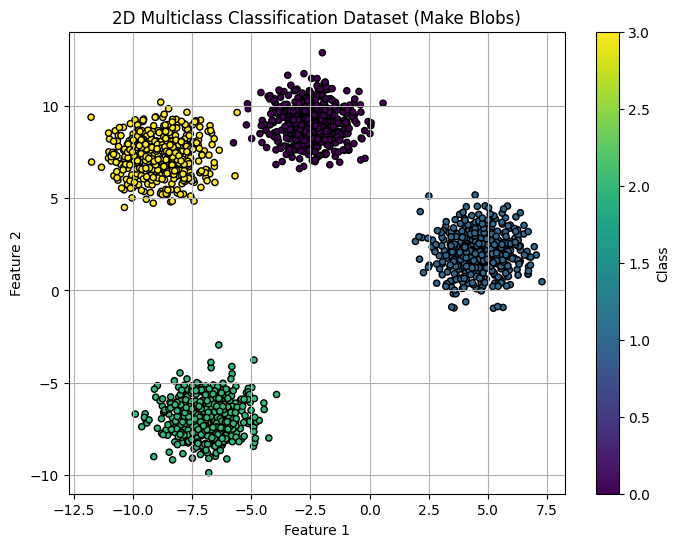

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(X_multi[:, 0], X_multi[:, 1], c=y_multi, cmap='viridis', s=20, edgecolor='k')
plt.title('2D Multiclass Classification Dataset (Make Blobs)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')
plt.grid(True)
plt.show()

In [28]:
X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(X_multi, y_multi, test_size=0.3, random_state=42)
print("Multiclass dataset split into training and testing sets successfully.")

Multiclass dataset split into training and testing sets successfully.


In [29]:
num_classes = len(np.unique(y_multi))
y_multi_train_one_hot = tf.keras.utils.to_categorical(y_multi_train, num_classes=num_classes)
y_multi_test_one_hot = tf.keras.utils.to_categorical(y_multi_test, num_classes=num_classes)
print("Multiclass labels converted to one-hot encoding successfully.")

Multiclass labels converted to one-hot encoding successfully.


In [30]:
input_shape_multi = X_multi_train.shape[1]

model_keras_multi = tf.keras.Sequential([
    tf.keras.Input(shape=(input_shape_multi,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

print("Keras multiclass model defined successfully.")
model_keras_multi.summary()

Keras multiclass model defined successfully.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,404 (9.39 KB)

 Trainable params: 2,404 (9.39 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model_keras_multi.compile(optimizer='adam',
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])
print("Keras multiclass model compiled successfully.")

Keras multiclass model compiled successfully.


In [32]:
history_keras_multi = model_keras_multi.fit(X_multi_train, y_multi_train_one_hot, epochs=100, batch_size=32, verbose=0, validation_split=0.2)
print("Keras multiclass model trained successfully.")

Keras multiclass model trained successfully.


In [33]:
model_sklearn_multi = MLPClassifier(hidden_layer_sizes=(64, 32),
                                  activation='relu',
                                  solver='adam',
                                  max_iter=500, # Increased max_iter for better convergence
                                  random_state=42)

print("Scikit-learn MLPClassifier for multiclass instantiated successfully.")

model_sklearn_multi.fit(X_multi_train, y_multi_train)
print("Scikit-learn MLPClassifier for multiclass trained successfully.")

Scikit-learn MLPClassifier for multiclass instantiated successfully.
Scikit-learn MLPClassifier for multiclass trained successfully.


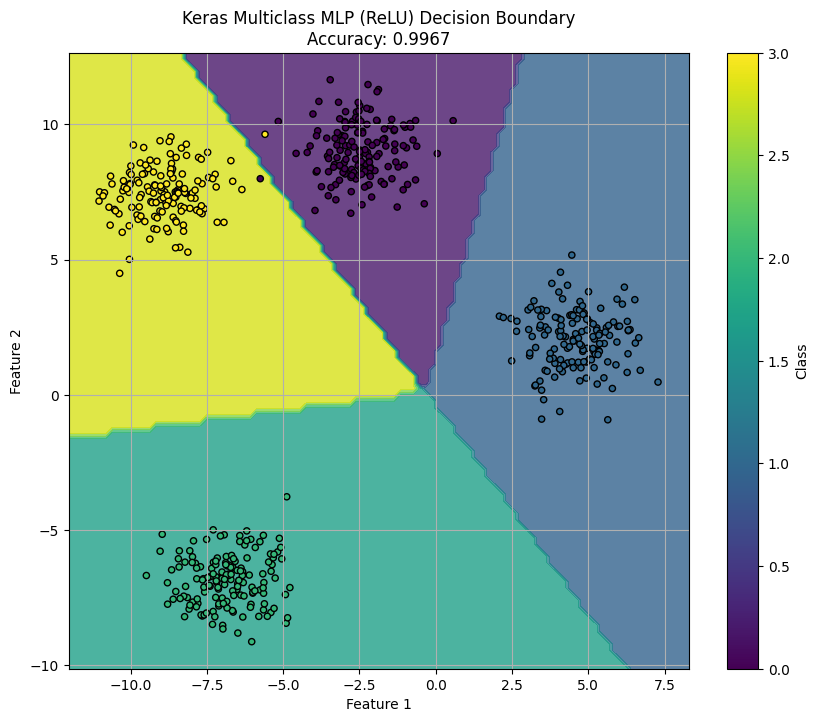

In [34]:
plot_multiclass_decision_boundary(model_keras_multi, X_multi_test, y_multi_test, y_multi_test_one_hot, 'Keras Multiclass MLP (ReLU) Decision Boundary')

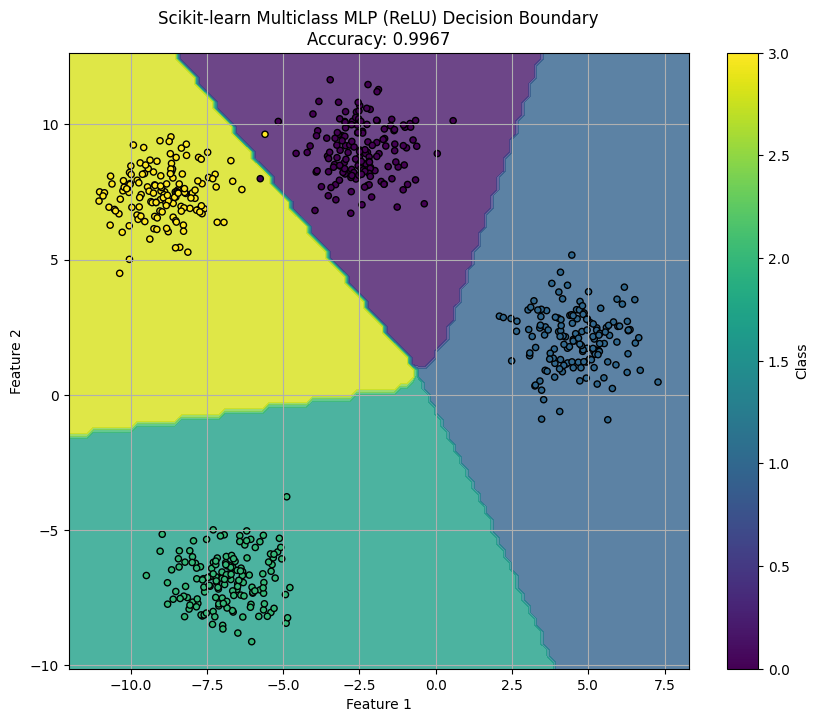

In [35]:
plot_multiclass_decision_boundary(model_sklearn_multi, X_multi_test, y_multi_test, y_multi_test_one_hot, 'Scikit-learn Multiclass MLP (ReLU) Decision Boundary')